In [2]:
# importing surrogate modelling toolbox to create lhs (latin hypercube sampling) distribution for out input a
from smt.sampling_methods import LHS

In [3]:
# importing some standards data manupulation librries 
import pandas as pd 
import numpy as np 
import seaborn as sns
import csv 

In [5]:
# log 1 : setting input ranges purely on instinctual basis keeping in mind basisc thermodynamic (rough)
    #update tuning the ranges to decrease high purity saturation in distillate purity
# log 2 : ussing tunned input ranges to get more converged results, since lot of results cam out un converged 
    # was getting exactly same values for every 3 consecutive values which gave terrible R^2 score 
    # upon further investigation and chaing the automation loops multiple times adding new methods and logging if converged 
    # method it was found out if column doesnt converge it just store the last output so now i made automation work such 
    # that only converged values are stored. 

xlimits1 = np.array([
    [295,380],#temp
    [1,3],#pressure
    [0.2,0.8],#benzenze composition 
    [15,45],# num stage
    [1.5,3.5],#reflux ratio
    [0.95,1.15],#bottom withdrawl rate fraction for sampling purpose
    [1.5,8],#molar flow
    [1.013,2.5],#stage 1 pressure
    [0.3,0.7] #Feed stage
])
# we will be using 7 of 7 compulsory input variables mentioned and 2 of 3 optional input variables mentioned in documentation 

In [7]:
# code of each attempt is stored and organized in different file to keep things clean but is available for reference or evaluation

In [7]:
# creating a well distributed sample in above mentioned ranges (xlimits1) with the criterion being enhanced stochastic evolutionary alg (ese)
sampling1 = LHS(
    xlimits = xlimits1,
    criterion = "ese" )

In [9]:
# calculating 4000 samples which is a large number for inputs itself but considering some of them wont converge 
x1 = sampling1(4000)

In [10]:
#creating dataframe form lhs sample with coloumns as lable
df1 = pd.DataFrame(x1,columns = ["Feed temperature","Feed pressure","Feed composition","Number of stages","Reflux ratio","Bottoms withdrawal rate","Molar flow","Column pressure","Feed Stage"])

In [11]:
#rouding up inputs like feed stage to make then into integers since only integers are accepted in dwsim
df1["Number of stages"] = df1["Number of stages"].round(0).astype(int)
#makeing the feed stage dependent on total stage the value provided by smt lhs being the percentage of total stages
df1["Feed Stage"] = df1["Feed Stage"]*df1["Number of stages"]
#turning feed stage into integer as well since stage can be fraction
df1["Feed Stage"] = df1["Feed Stage"].round(0).astype(int)

In [12]:
# calculation and setting bottom withdrawl rate values 
df1["Bottoms withdrawal rate"] = (df1["Molar flow"] * ( 1 - df1["Feed composition"]))*df1["Bottoms withdrawal rate"]

In [13]:
df1

,Feed temperature,Feed pressure,Feed composition,Number of stages,Reflux ratio,Bottoms withdrawal rate,Molar flow,Column pressure,Feed Stage
0,329.475390,1.066954,0.253453,31,2.219619,2.717732,3.460038,1.536538,20
1,322.117829,2.813161,0.238420,16,2.573843,4.893621,6.432262,2.448703,10
2,330.801948,1.904005,0.215137,18,1.994737,1.326680,1.536966,1.981900,11
3,368.338860,1.852737,0.431656,39,2.997927,2.379202,3.920070,1.818978,20
4,329.719518,1.676682,0.303383,39,2.340097,2.140200,3.118924,1.537435,13
...,...,...,...,...,...,...,...,...,...
3995,300.562091,2.838238,0.381572,43,1.601167,2.189349,3.101681,2.126879,27
3996,309.966438,1.519559,0.343523,19,3.200086,4.157797,5.753005,1.243543,8
3997,358.258419,1.008408,0.506693,24,1.683957,3.361327,6.455789,1.930222,16
3998,319.106983,2.920969,0.395469,16,1.515257,2.483191,3.972297,1.451393,6


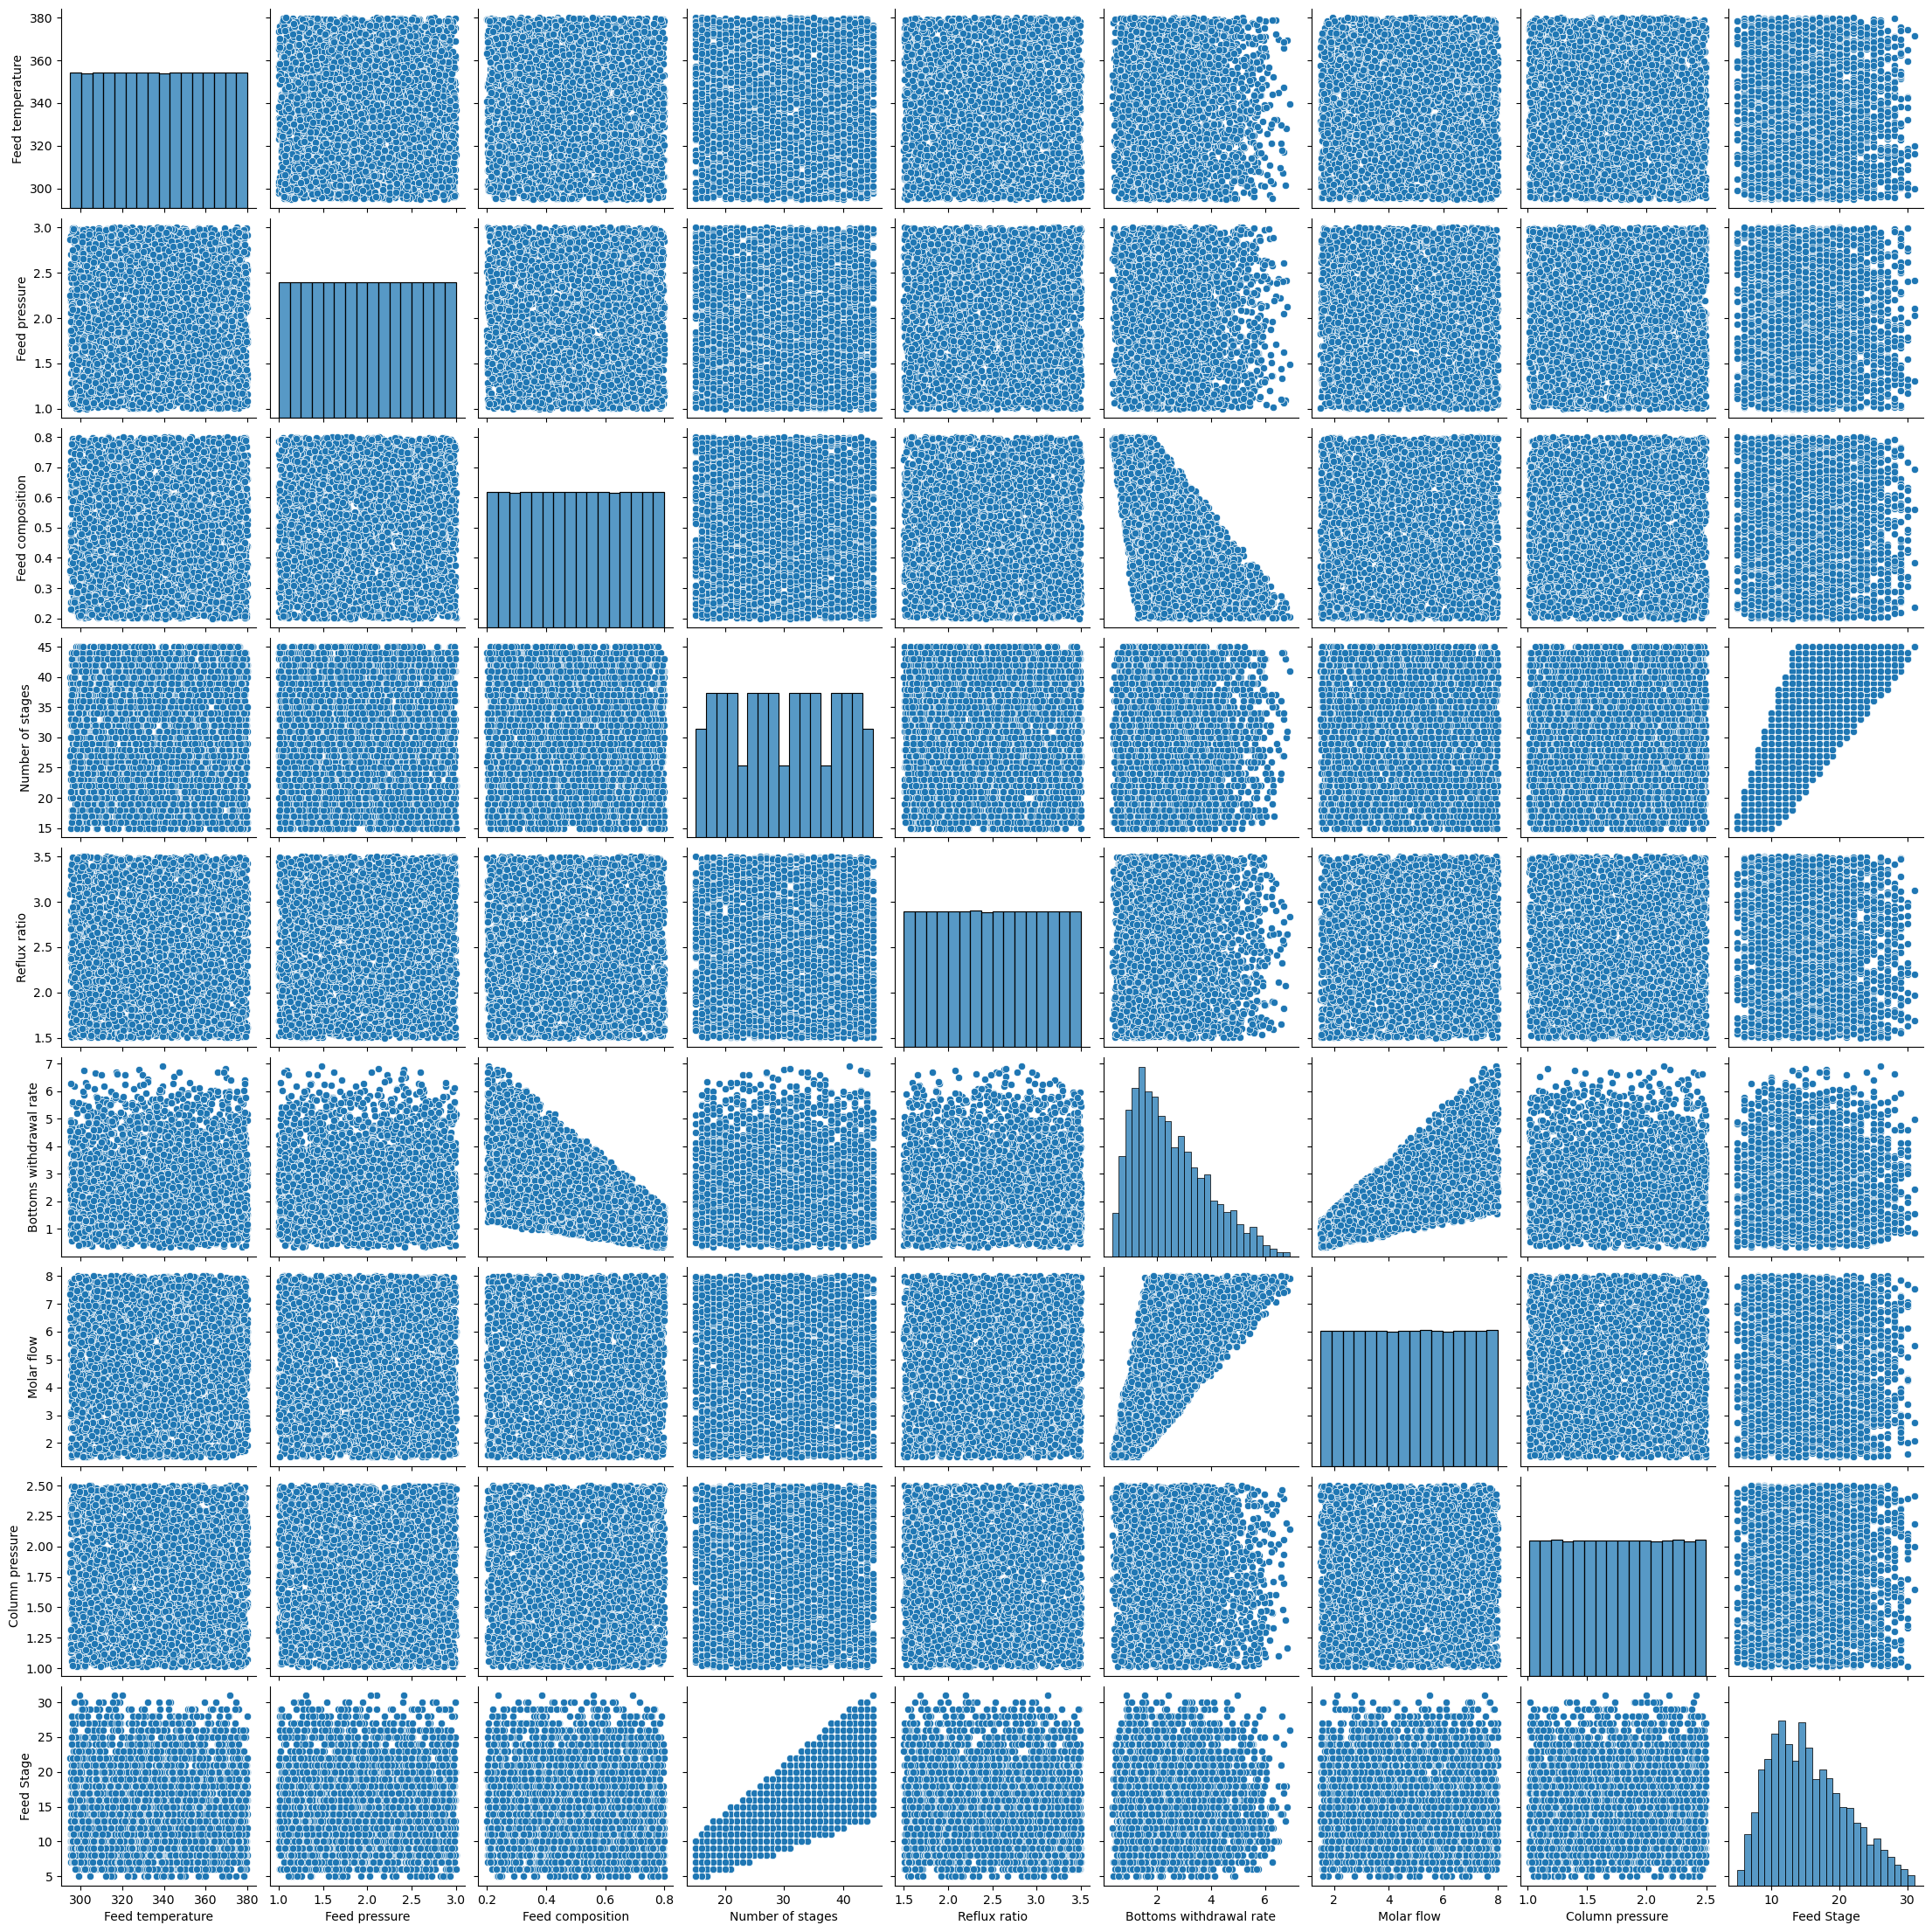

In [14]:
#performing visual representation to spectate the distribution (cross check)
sns.pairplot(df1)

In [15]:
df1.describe().T[["min", "max", "mean", "std"]]

,min,max,mean,std
Feed temperature,295.020545,379.996853,337.500009,24.540463
Feed pressure,1.000236,2.999801,2.000000,0.577420
Feed composition,0.200050,0.799932,0.500000,0.173228
Number of stages,15.000000,45.000000,30.000000,8.670772
Reflux ratio,1.500081,3.499982,2.500000,0.577428
Bottoms withdrawal rate,0.333099,6.902827,2.492197,1.360173
Molar flow,1.500292,7.998563,4.749998,1.876621
Column pressure,1.013265,2.499806,1.756498,0.429316
Feed Stage,5.000000,31.000000,14.996500,5.653581


In [17]:
#turning df1 into csv file to access in another notebook where automation of calculation using dwsim's dlls will take place 
df1.to_csv("4kinput",index = False)